# E-Commerce Sales Analysis using SQL and Python

## Objective

The objective of this project is to analyze an e-commerce dataset to identify sales trends, customer behavior, product performance, seller performance, payment preferences, and delivery insights using SQL and Python.

## Tools Used

- SQL (MySQL)
- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

# 📊 Data Loading & Exploratory Data Analysis

## Objective

Before performing business analysis, the datasets were loaded into Python using Pandas and explored to understand their structure, identify missing values, check data quality, and gain initial insights.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📊 Data Loading & Exploratory Data Analysis (EDA)

## Objective

The objective of this section is to load all datasets into Python, understand their structure, assess data quality, identify missing values and duplicates, and perform initial exploration before conducting business analysis.

In [23]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
payments = pd.read_csv("payments.csv")
products = pd.read_csv("products.csv")
sellers = pd.read_csv("sellers.csv")
geolocation = pd.read_csv("geolocation.csv")

## Customers Dataset

In [17]:
customers.head()

customers.shape

(99441, 5)

In [19]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [21]:
customers.isnull().sum()

customers.duplicated().sum()

0

In [22]:
customers.describe(include="all")

customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

## Orders Dataset

In [25]:
orders.head()

orders.shape

(99441, 8)

In [26]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [100]:
orders.isnull().sum()

# orders.duplicated().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [29]:
orders.describe(include="all")

orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [31]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Order Items Dataset

In [36]:
order_items.head()
order_items.shape

(112650, 7)

In [38]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [42]:
order_items.isnull().sum()
order_items.duplicated().sum()

0

In [45]:
order_items.describe()
order_items.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [48]:
order_items[["price","freight_value"]].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


## Products Dataset

In [51]:
products.head()
products.shape

(32951, 9)

In [54]:
products.isnull().sum()
products.duplicated().sum()


0

In [56]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product category            32341 non-null  object 
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [60]:
products.describe(include = "all")
products.nunique()

product_id                    32951
product category                 73
product_name_length              66
product_description_length     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

In [64]:
products["product category"].value_counts().head(10)

product category
bed table bath          3029
sport leisure           2867
Furniture Decoration    2657
HEALTH BEAUTY           2444
housewares              2335
automotive              1900
computer accessories    1639
toys                    1411
Watches present         1329
telephony               1134
Name: count, dtype: int64

In [66]:
products["product category"].nunique()

73

## Payments Dataset

In [68]:
payments.head()

payments.shape

(103886, 5)

In [70]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [71]:
payments.isnull().sum()

payments.duplicated().sum()

0

In [72]:
payments.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

In [74]:
payments["payment_type"].value_counts()

payment_type
credit_card    76795
UPI            19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [76]:
payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

## Sellers Dataset

In [78]:
sellers.head()

sellers.shape

(3095, 4)

In [79]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [81]:
sellers.isnull().sum()

sellers.duplicated().sum()

0

In [83]:
sellers.nunique()

seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

In [85]:
sellers["seller_state"].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
PI       1
AC       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

## Geolocation Dataset

In [95]:
geolocation.head(10)

geolocation.shape

(1000163, 5)

In [89]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [96]:
geolocation.isnull().sum()

geolocation.duplicated().sum()

261831

In [98]:
geolocation.nunique()

geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64

In [99]:
geolocation["geolocation_state"].value_counts()

geolocation_state
SP    404268
MG    126336
RJ    121169
RS     61851
PR     57859
SC     38328
BA     36045
GO     20139
ES     16748
PE     16432
DF     12986
MT     12031
CE     11674
PA     10853
MS     10431
MA      7853
PB      5538
RN      5041
PI      4549
AL      4183
TO      3576
SE      3563
RO      3478
AM      2432
AC      1301
AP       853
RR       646
Name: count, dtype: int64

# Key Findings

- Successfully loaded and explored all seven datasets using Pandas.
- Dataset structure, data types, and record counts were verified before analysis.
- The Products dataset contains a small number of missing values in product-related attributes.
- The Orders dataset contains missing values in delivery-related columns, primarily for incomplete or cancelled orders.
- The Geolocation dataset contains 261,831 duplicate records, which were retained as they represent expected duplicate geographical entries and were     not directly used in the business analysis.
- No major data quality issues were identified that would significantly impact the business analysis.
- The datasets were considered suitable for SQL-based business analysis and visualization.

In [101]:
print("\n")

In [105]:
import mysql.connector
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [106]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345",
    database="ecommerce"
)

cur = conn.cursor()

# 📊 Key Performance Indicators (KPIs)

In [23]:
# KPI 1: Total Revenue

query = """
SELECT ROUND(SUM(price),2) AS total_revenue
FROM order_items;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Total Revenue"])
df

,Total Revenue
0,"13,591,643.70"


In [24]:
# KPI 2: Total Orders
query = """
SELECT COUNT(DISTINCT order_id) AS total_orders
FROM orders;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Total Orders"])
df

,Total Orders
0,99441


In [25]:
# KPI 3: Total Customers
query = """
SELECT COUNT(DISTINCT customer_id) AS total_customers
FROM customers;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Total Customers"])
df

,Total Customers
0,99441


In [26]:
# KPI 4: Total Sellers
query = """
SELECT COUNT(DISTINCT seller_id) AS total_sellers
FROM sellers;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Total Sellers"])
df

,Total Sellers
0,3095


In [27]:
# KPI 5: Total Products Sold
query = """
SELECT COUNT(*) AS total_products_sold
FROM order_items;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Total Products Sold"])
df

,Total Products Sold
0,112650


In [29]:
# KPI 6: Average Order Value (AOV)
query = """
SELECT ROUND(SUM(price)/COUNT(DISTINCT order_id),2) AS average_order_value
FROM order_items;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Average Order Value"])
df

,Average Order Value
0,137.75


In [30]:
# KPI 7: Average Delivery Time (Days)
query = """
SELECT ROUND(AVG(DATEDIFF(order_delivered_customer_date,
order_purchase_timestamp)),2) AS avg_delivery_days
FROM orders
WHERE order_delivered_customer_date IS NOT NULL;
"""

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns=["Average Delivery Days"])
df

,Average Delivery Days
0,12.50


# 📈 Sales Analysis

## Sales Analysis 1: Monthly Revenue Trend

**Business Question:**
How has monthly revenue changed over time?

    Year  Month No     Month      Revenue
0   2016         9  2016-Sep       267.36
1   2016        10  2016-Oct    49,507.66
2   2016        12  2016-Dec        10.90
3   2017         1  2017-Jan   120,312.87
4   2017         2  2017-Feb   247,303.02
5   2017         3  2017-Mar   374,344.30
6   2017         4  2017-Apr   359,927.23
7   2017         5  2017-May   506,071.14
8   2017         6  2017-Jun   433,038.60
9   2017         7  2017-Jul   498,031.48
10  2017         8  2017-Aug   573,971.68
11  2017         9  2017-Sep   624,401.69
12  2017        10  2017-Oct   664,219.43
13  2017        11  2017-Nov 1,010,271.37
14  2017        12  2017-Dec   743,914.17
15  2018         1  2018-Jan   950,030.36
16  2018         2  2018-Feb   844,178.71
17  2018         3  2018-Mar   983,213.44
18  2018         4  2018-Apr   996,647.75
19  2018         5  2018-May   996,517.68
20  2018         6  2018-Jun   865,124.31
21  2018         7  2018-Jul   895,507.22
22  2018         8  2018-Aug   854

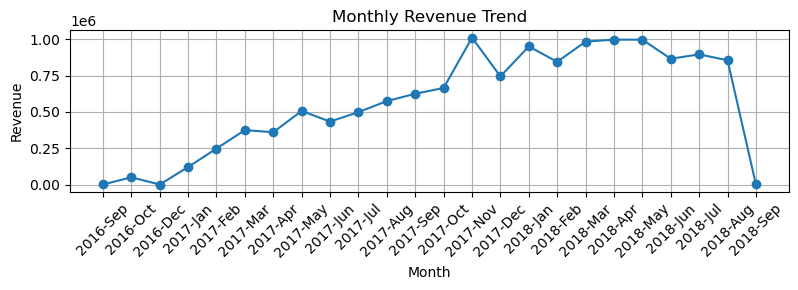

In [38]:
# Sales Analysis 1: Monthly Revenue Trend

query = """SELECT
    YEAR(o.order_purchase_timestamp) AS year,
    MONTH(o.order_purchase_timestamp) AS month_no,
    DATE_FORMAT(o.order_purchase_timestamp,'%Y-%b') AS month,
    ROUND(SUM(oi.price),2) AS revenue
FROM orders o
JOIN order_items oi
ON o.order_id = oi.order_id
GROUP BY
YEAR(o.order_purchase_timestamp),
MONTH(o.order_purchase_timestamp),
DATE_FORMAT(o.order_purchase_timestamp,'%Y-%b')
ORDER BY year,month_no;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns=["Year","Month No","Month","Revenue"])

print(df)

plt.figure(figsize=(8,3))

plt.plot(df["Month"], df["Revenue"], marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid()

plt.tight_layout()

plt.show()

#### Key Insights
- Monthly revenue showed a strong upward trend from 2016 to 2018.
- November 2017 recorded the highest monthly revenue (1.01M), indicating a strong seasonal sales period.
- The very low revenue in December 2016 and September 2018 is due to incomplete monthly data and should not be treated as a business decline.

#### Recommendation
- Increase inventory and marketing efforts before peak sales months.
- Exclude incomplete months from trend analysis to ensure accurate reporting.

In [60]:
print("\n")

## Sales Analysis 2: Revenue by State

**Business Question:**
Which customer states generate the highest revenue?

  State      Revenue
0    SP 5,202,955.05
1    RJ 1,824,092.67
2    MG 1,585,308.03
3    RS   750,304.02
4    PR   683,083.76
5    SC   520,553.34
6    BA   511,349.99
7    DF   302,603.94
8    GO   294,591.95
9    ES   275,037.31
State       object
Revenue    float64
dtype: object


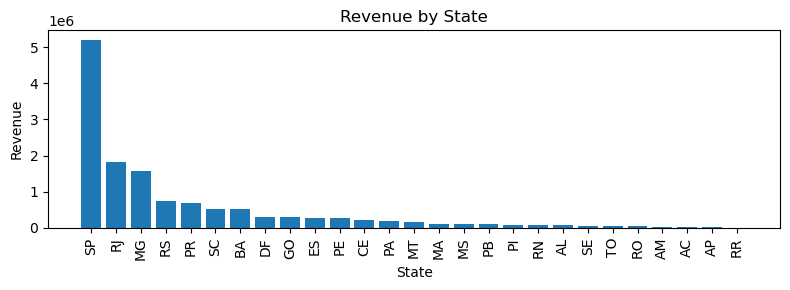

In [43]:
# Sales Analysis 2: Revenue by State

query = """
SELECT
    c.customer_state,
    ROUND(SUM(oi.price),2) AS revenue
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY revenue DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["State", "Revenue"])

print(df.head(10))
print(df.dtypes)

plt.figure(figsize=(8,3))

plt.bar(df["State"], df["Revenue"])

plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

#### Key Insights

- São Paulo (SP) generated the highest revenue (5.20M), significantly outperforming all other states.
- Revenue is highly concentrated in the top three states (SP, RJ, and MG).
- Lower revenue in states such as DF, GO, and ES indicates untapped market potential.

#### Business Recommendations

- Maintain strong inventory and customer engagement in high-performing states.
- Increase regional marketing and promotional campaigns in lower-performing states to expand market reach.

In [62]:
print("\n")

## Sales Analysis 3: Revenue by City

**Business Question:**
Which customer cities generate the highest revenue?

             City      Revenue
0       SAO PAULO 1,914,924.54
1  RIO DE JANEIRO   992,538.86
2  BELO HORIZONTE   355,611.13
3        BRASILIA   301,920.25
4        CURITIBA   211,738.06
5    PORTO ALEGRE   190,562.08
6        CAMPINAS   187,844.53
7        SALVADOR   181,104.42
8       GUARULHOS   144,268.39
9         NITEROI   117,907.12


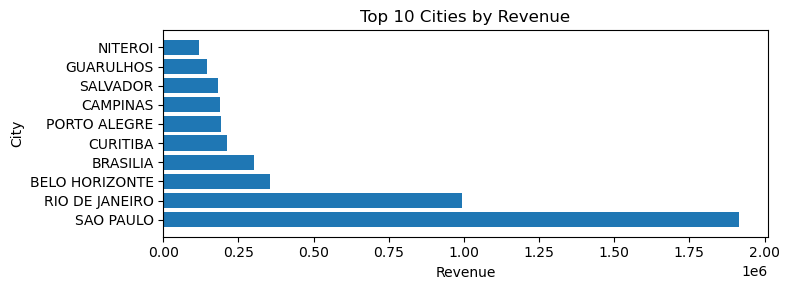

In [50]:
# Sales Analysis 3: Top 10 Cities by Revenue

query = """
SELECT
    UPPER(c.customer_city) AS city,
    ROUND(SUM(oi.price),2) AS revenue
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_city
ORDER BY revenue DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["City","Revenue"])

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["City"], df["Revenue"])

plt.title("Top 10 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.tight_layout()

plt.show()

#### Key Insights

- São Paulo generated the highest revenue (1.91M), followed by Rio de Janeiro (0.99M), making them the strongest revenue-generating cities.
- Revenue is concentrated in a small number of metropolitan cities, indicating a strong urban customer base.
- Cities such as Brasília, Curitiba, and Porto Alegre also contributed significantly but remain far behind the top two cities.

#### Business Recommendations

- Continue strengthening customer engagement and inventory planning in high-revenue cities to sustain growth.
- Expand targeted marketing campaigns and logistics capabilities in mid-performing cities to increase market penetration.

In [64]:
print("\n")

## Sales Analysis 4: Year-over-Year Revenue Growth

**Business Question:**
How has the company's revenue grown year over year?

   Year      Revenue  Previous Year Revenue  YoY Growth (%)
0  2016    49,785.92                    NaN             NaN
1  2017 6,155,806.98              49,785.92       12,264.55
2  2018 7,386,050.80           6,155,806.98           19.99


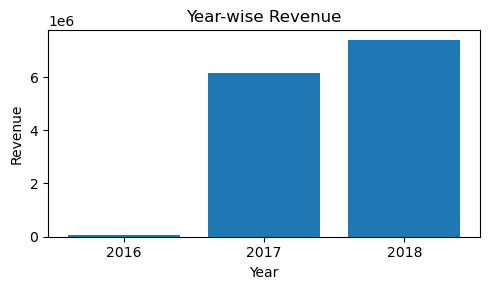

In [54]:
# Sales Analysis 4: Year-over-Year Revenue Growth

query = """WITH yearly_sales AS (
    SELECT
        YEAR(o.order_purchase_timestamp) AS year,
        ROUND(SUM(oi.price),2) AS revenue
    FROM orders o
    JOIN order_items oi
        ON o.order_id = oi.order_id
    GROUP BY YEAR(o.order_purchase_timestamp)
)

SELECT
    year,
    revenue,
    LAG(revenue) OVER(ORDER BY year) AS previous_year_revenue,
    ROUND(
        ((revenue - LAG(revenue) OVER(ORDER BY year))
        / LAG(revenue) OVER(ORDER BY year)) * 100,
        2
    ) AS yoy_growth_pct
FROM yearly_sales;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Year", "Revenue", "Previous Year Revenue", "YoY Growth (%)"]
)

print(df)

plt.figure(figsize=(5,3))

plt.bar(df["Year"].astype(str), df["Revenue"])

plt.title("Year-wise Revenue")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

#### Insights

- Revenue increased significantly from **49.8K in 2016** to **6.16M in 2017**.
- Revenue continued to grow in **2018**, reaching **7.39M**, with a **19.99% YoY growth**.
- The exceptionally high growth in 2017 is influenced by the limited sales data available for 2016.

#### Recommendations

- Maintain growth by continuing successful sales and marketing strategies.
- Exclude incomplete years from YoY comparisons to ensure more accurate performance evaluation.

In [57]:
print("\n")

# 📦 Product Analysis

## Product Analysis 1: Top 10 Product Categories by Revenue

**Business Question:**
Which product categories generate the highest revenue?

               Category      Revenue
0         HEALTH BEAUTY 1,258,681.34
1       WATCHES PRESENT 1,205,005.68
2        BED TABLE BATH 1,036,988.68
3         SPORT LEISURE   988,048.97
4  COMPUTER ACCESSORIES   911,954.32
5  FURNITURE DECORATION   729,762.49
6            COOL STUFF   635,290.85
7            HOUSEWARES   632,248.66
8            AUTOMOTIVE   592,720.11
9          GARDEN TOOLS   485,256.46


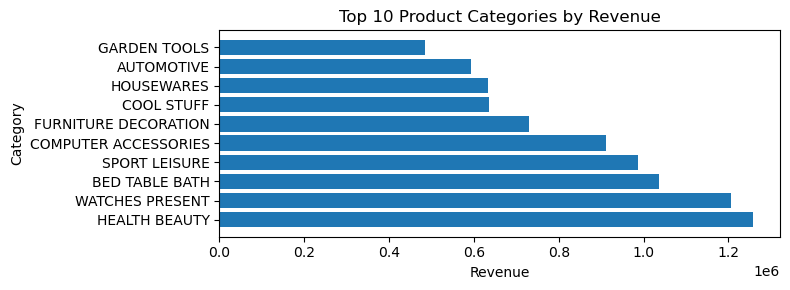

In [60]:
# Product Analysis 1: Top 10 Product Categories by Revenue

query = """
SELECT
    UPPER(p.product_category) AS category,
    ROUND(SUM(oi.price),2) AS revenue
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY p.product_category
ORDER BY revenue DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category", "Revenue"])

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["Category"], df["Revenue"])

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

#### Insights

- Health Beauty generated the highest revenue (1.26M), followed closely by Watches Present (1.21M).
- The top product categories contribute a significant share of overall revenue, indicating strong customer demand in these segments.
- Categories such as Furniture Decoration, Housewares, and Garden Tools also performed well, showing a diverse product portfolio.

#### Recommendations

- Prioritize inventory and promotional campaigns for top-performing product categories to sustain revenue growth.
- Develop targeted marketing strategies for mid-performing categories to increase their sales contribution.

In [65]:
print("\n")

## Product Analysis 2: Revenue Contribution by Product Category

**Business Question:**
What percentage of total revenue is contributed by each product category?

               Category     Revenue  Revenue Percentage
0         HEALTH BEAUTY  1258681.34                9.26
1       WATCHES PRESENT  1205005.68                8.87
2        BED TABLE BATH  1036988.68                7.63
3         SPORT LEISURE   988048.97                7.27
4  COMPUTER ACCESSORIES   911954.32                6.71
5  FURNITURE DECORATION   729762.49                5.37
6            COOL STUFF   635290.85                4.67
7            HOUSEWARES   632248.66                4.65
8            AUTOMOTIVE   592720.11                4.36
9          GARDEN TOOLS   485256.46                3.57


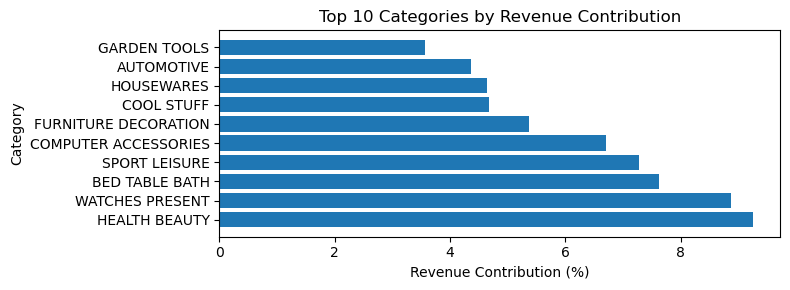

In [4]:
# Product Analysis 2: Revenue Contribution by Product Category

query = """
WITH category_revenue AS (
    SELECT
        UPPER(p.product_category) AS category,
        ROUND(SUM(oi.price),2) AS revenue
    FROM products p
    JOIN order_items oi
        ON p.product_id = oi.product_id
    GROUP BY p.product_category
)

SELECT
    category,
    revenue,
    ROUND((revenue / SUM(revenue) OVER()) * 100,2) AS revenue_percentage
FROM category_revenue
ORDER BY revenue DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category", "Revenue", "Revenue Percentage"])

print(df.head(10))

top10 = df.head(10)

plt.figure(figsize=(8,3))

plt.barh(top10["Category"], top10["Revenue Percentage"])

plt.title("Top 10 Categories by Revenue Contribution")
plt.xlabel("Revenue Contribution (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


#### Insights

- Health Beauty contributed the largest share of total revenue (9.26%), followed by Watches Present (8.87%).
- The top 10 product categories together account for a substantial portion of overall revenue, indicating that sales are concentrated in a limited number of categories.
- No single category dominates the business, suggesting a well-diversified product portfolio.

#### Recommendations

- Continue investing in high-contributing categories while maintaining product availability.
- Improve the performance of lower-contributing categories through targeted promotions and category-specific marketing campaigns.

In [66]:
print("\n")

## Product Analysis 3: Top 10 Product Categories by Quantity Sold

**Business Question:**
Which product categories have sold the highest number of products?

               Category  Quantity Sold
0        BED TABLE BATH          11115
1         HEALTH BEAUTY           9670
2         SPORT LEISURE           8641
3  FURNITURE DECORATION           8334
4  COMPUTER ACCESSORIES           7827
5            HOUSEWARES           6964
6       WATCHES PRESENT           5991
7             TELEPHONY           4545
8          GARDEN TOOLS           4347
9            AUTOMOTIVE           4235


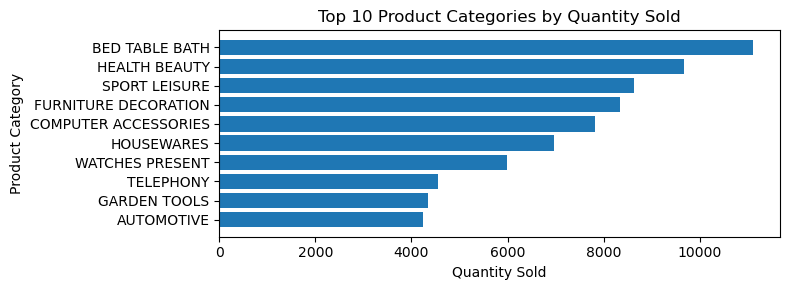

In [69]:
# Product Analysis 3: Top 10 Product Categories by Quantity Sold

query = """
SELECT
    UPPER(p.product_category) AS category,
    COUNT(oi.order_item_id) AS quantity_sold
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY p.product_category
ORDER BY quantity_sold DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category", "Quantity Sold"])

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["Category"], df["Quantity Sold"])

plt.title("Top 10 Product Categories by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- Bed Table Bath recorded the highest number of units sold (11,115), followed by Health Beauty (9,670).
- High sales volume does not always correspond to the highest revenue, indicating differences in product pricing across categories.
- Customer demand is strongest for everyday-use and lifestyle product categories.

#### Recommendations

- Ensure sufficient inventory for high-demand categories to prevent stock-outs.
- Bundle or cross-sell high-volume products with premium products to increase overall revenue.

In [68]:
print("\n")

## Product Analysis 4: Top 10 Best-Selling Products

**Business Question:**
Which products have been purchased the most times?

                         Product ID              Category  Quantity Sold  \
0  aca2eb7d00ea1a7b8ebd4e68314663af  FURNITURE DECORATION            527   
1  99a4788cb24856965c36a24e339b6058        BED TABLE BATH            488   
2  422879e10f46682990de24d770e7f83d          GARDEN TOOLS            484   
3  389d119b48cf3043d311335e499d9c6b          GARDEN TOOLS            392   
4  368c6c730842d78016ad823897a372db          GARDEN TOOLS            388   
5  53759a2ecddad2bb87a079a1f1519f73          GARDEN TOOLS            373   
6  d1c427060a0f73f6b889a5c7c61f2ac4  COMPUTER ACCESSORIES            343   
7  53b36df67ebb7c41585e8d54d6772e08       WATCHES PRESENT            323   
8  154e7e31ebfa092203795c972e5804a6         HEALTH BEAUTY            281   
9  3dd2a17168ec895c781a9191c1e95ad7  COMPUTER ACCESSORIES            274   

    Revenue  
0  37608.90  
1  43025.56  
2  26577.22  
3  21440.59  
4  21056.80  
5  20387.20  
6  47214.51  
7  37683.42  
8   6325.19  
9  41082.60  


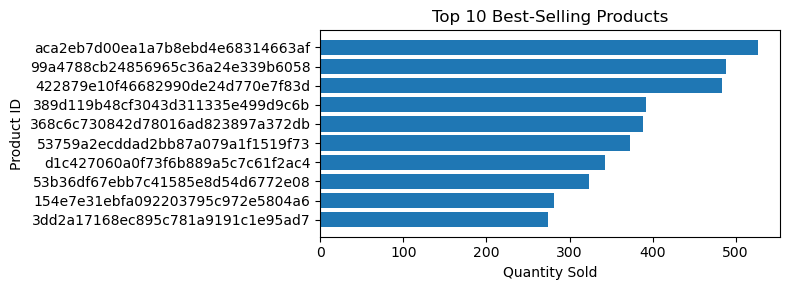

In [11]:
# Product Analysis 4: Top 10 Best-Selling Products

query = """
SELECT
    p.product_id,
    UPPER(p.product_category) AS category,
    COUNT(oi.order_item_id) AS total_quantity_sold,
    ROUND(SUM(oi.price),2) AS revenue
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY p.product_id, p.product_category
ORDER BY total_quantity_sold DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Product ID", "Category", "Quantity Sold", "Revenue"]
)

print(df)


plt.figure(figsize=(8,3))

plt.barh(
    df["Product ID"].astype(str),
    df["Quantity Sold"]
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- The best-selling product belongs to the Furniture Decoration category, with 527 units sold.
- Garden Tools appears multiple times in the top-selling products list, indicating consistently high customer demand within this category.
- Some products generated high revenue despite lower sales volume, suggesting they have a higher selling price.

#### Recommendations

- Maintain adequate inventory for top-selling products to avoid stock shortages.
- Promote high-revenue products alongside high-volume products to maximize overall sales and profitability.

In [70]:
print("\n")

## Product Analysis 5: Average Product Price by Category

**Business Question:**
Which product categories have the highest average selling price?

                          Category  Average Price
0                              PCS        1098.34
1      HOUSE PASTALS OVEN AND CAFE         624.29
2                     ELECTRICES 2         476.12
3        AGRO INDUSTRIA E COMERCIO         342.12
4              MUSICAL INSTRUMENTS         281.62
5                     ELECTROSTILE         280.78
6  KITCHEN PORTABLE AND FOOD COACH         264.57
7                  FIXED TELEPHONY         225.69
8      CONSTRUCTION SECURITY TOOLS         208.99
9                  WATCHES PRESENT         201.14


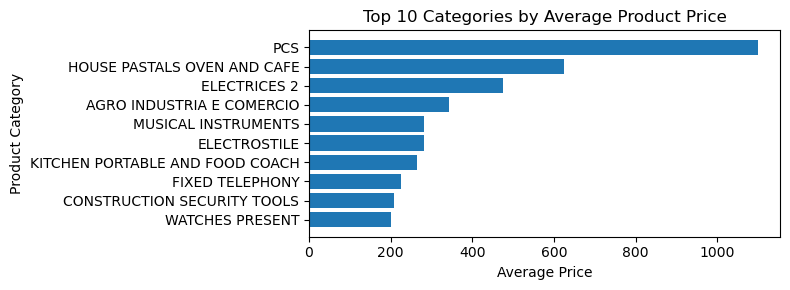

In [14]:
# Product Analysis 5: Average Product Price by Category

query = """
SELECT
    UPPER(p.product_category) AS category,
    ROUND(AVG(oi.price),2) AS average_price
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY p.product_category
ORDER BY average_price DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Category", "Average Price"])

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["Category"], df["Average Price"])

plt.title("Top 10 Categories by Average Product Price")
plt.xlabel("Average Price")
plt.ylabel("Product Category")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- PCS recorded the highest average product price (1,098.34), followed by House Pastals Oven and Cafe (624.29).
- Premium-priced categories generate higher revenue per unit but may have lower sales volume.
- Product pricing varies significantly across categories, reflecting different customer segments and market positioning.

#### Recommendations

- Focus on premium product categories by highlighting their value through targeted marketing.
- Maintain a balanced product portfolio with both premium and affordable categories to serve diverse customer needs.

In [71]:
print("\n")

## Product Analysis 6: Relationship Between Product Price and Purchase Frequency

**Business Question:**
Is there a relationship between product price and purchase frequency?

                         Product ID  Average Price  Purchase Frequency
0  310ae3c140ff94b03219ad0adc3c778f         145.95                   2
1  8cab8abac59158715e0d70a36c807415          99.90                   2
2  b50c950aba0dcead2c48032a690ce817          99.00                   4
3  5ed9eaf534f6936b51d0b6c5e4d5c2e9          24.98                  21
4  35537536ed2b4c561b4018bf3abf54e0         382.31                  13




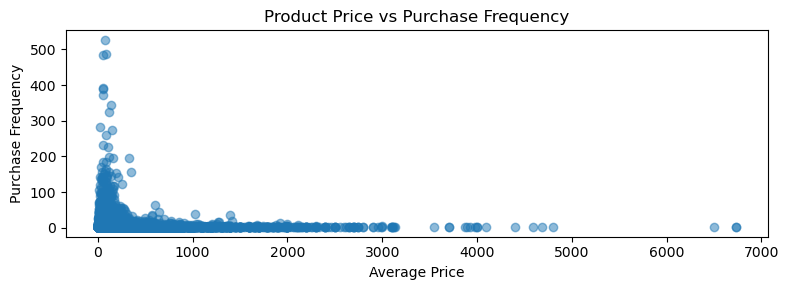



Correlation: -0.032


In [19]:
# Product Analysis 6: Product Price vs Purchase Frequency

query = """
SELECT
    p.product_id,
    ROUND(AVG(oi.price),2) AS average_price,
    COUNT(oi.order_item_id) AS purchase_frequency
FROM products p
JOIN order_items oi
    ON p.product_id = oi.product_id
GROUP BY p.product_id;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Product ID", "Average Price", "Purchase Frequency"]
)

print(df.head())
print("\n")
plt.figure(figsize=(8,3))

plt.scatter(
    df["Average Price"],
    df["Purchase Frequency"],
    alpha=0.5
)

plt.title("Product Price vs Purchase Frequency")
plt.xlabel("Average Price")
plt.ylabel("Purchase Frequency")

plt.tight_layout()

plt.show()

#Correlation

correlation = df["Average Price"].corr(df["Purchase Frequency"])
print("\n")
print(f"Correlation: {correlation:.3f}")



#### Insights

- The correlation between average product price and purchase frequency is **-0.032**, indicating almost no relationship between product price and customer purchase frequency.
- Both high-priced and low-priced products can achieve strong sales performance depending on customer demand.
- Product popularity appears to be influenced by factors other than price, such as product category, quality, brand, and customer preferences.

#### Recommendations

- Focus on improving product quality, customer experience, and marketing strategies rather than relying solely on pricing.
- Analyze additional factors such as product ratings, reviews, and category performance to better understand purchasing behavior.

In [20]:
print("\n")

# 👤 Customer Analysis

## Customer Analysis 1: Top 10 Customer Cities by Number of Customers

**Business Question:**
Which customer cities have the highest number of customers?

           Customer City  Total Customers
0              SAO PAULO            15540
1         RIO DE JANEIRO             6882
2         BELO HORIZONTE             2773
3               BRASILIA             2131
4               CURITIBA             1521
5               CAMPINAS             1444
6           PORTO ALEGRE             1379
7               SALVADOR             1245
8              GUARULHOS             1189
9  SAO BERNARDO DO CAMPO              938


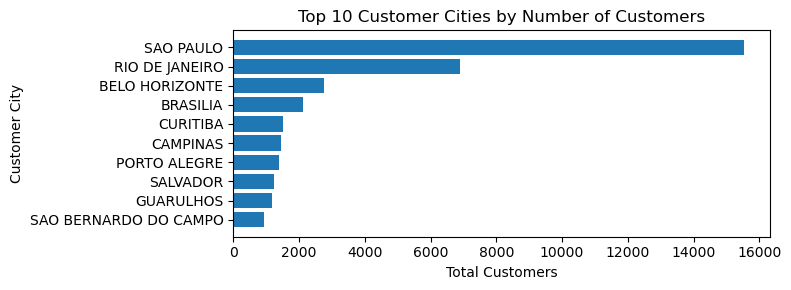

In [23]:
# Customer Analysis 1: Top 10 Customer Cities by Number of Customers

query = """
SELECT
    UPPER(customer_city) AS customer_city,
    COUNT(DISTINCT customer_id) AS total_customers
FROM customers
GROUP BY customer_city
ORDER BY total_customers DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Customer City", "Total Customers"])

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["Customer City"], df["Total Customers"])

plt.title("Top 10 Customer Cities by Number of Customers")
plt.xlabel("Total Customers")
plt.ylabel("Customer City")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- São Paulo has the largest customer base (15,540), followed by Rio de Janeiro (6,882).
- Customers are highly concentrated in major metropolitan cities, indicating stronger demand in urban regions.
- The customer distribution highlights significant opportunities for business expansion beyond the top cities.

#### Recommendations

- Strengthen customer retention and loyalty programs in cities with the highest customer concentration.
- Increase marketing efforts and regional campaigns in emerging cities to expand the customer base.

In [74]:
print("\n")

## Customer Analysis 2: Top 10 Customers by Revenue

**Business Question:**
Which customers have generated the highest revenue?

                        Customer ID  Revenue  Total Orders
0  1617b1357756262bfa56ab541c47bc16  13440.0             1
1  ec5b2ba62e574342386871631fafd3fc   7160.0             1
2  c6e2731c5b391845f6800c97401a43a9   6735.0             1
3  f48d464a0baaea338cb25f816991ab1f   6729.0             1
4  3fd6777bbce08a352fddd04e4a7cc8f6   6499.0             1
5  05455dfa7cd02f13d132aa7a6a9729c6   5934.6             1
6  df55c14d1476a9a3467f131269c2477f   4799.0             1
7  24bbf5fd2f2e1b359ee7de94defc4a15   4690.0             1
8  e0a2412720e9ea4f26c1ac985f6a7358   4599.9             1
9  3d979689f636322c62418b6346b1c6d2   4590.0             1




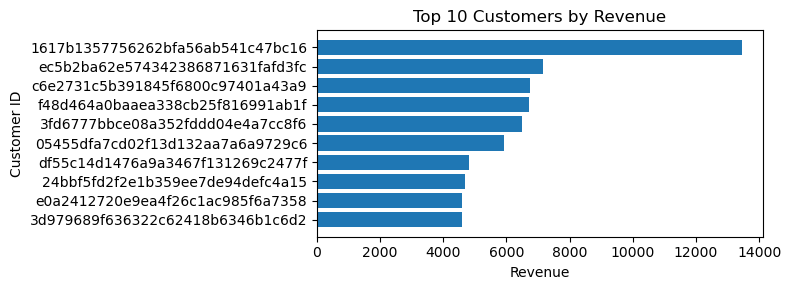

In [107]:
# Customer Analysis 2: Top 10 Customers by Revenue

query = """
SELECT
    c.customer_id,
    ROUND(SUM(oi.price),2) AS revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_id
ORDER BY revenue DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Customer ID", "Revenue", "Total Orders"]
)

print(df)
print("\n")

plt.figure(figsize=(8,3))

plt.barh(
    df["Customer ID"].astype(str),
    df["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- The highest-spending customer generated **13,440** in revenue from a single order.
- All top revenue-generating customers placed only **one order**, indicating that high-value purchases are not necessarily linked to repeat buying.
- Customer value varies significantly based on order amount rather than purchase frequency.

#### Recommendations

- Introduce loyalty programs and personalized offers to encourage repeat purchases from high-value customers.
- Identify high-spending customers and target them with premium products and exclusive promotions to improve customer lifetime value.

In [75]:
print("\n")

## Customer Analysis 3: Customer Segmentation by Revenue

**Business Question:**
How can customers be segmented based on their total spending?

  Customer Segment  Total Customers  Average Spending
0       High Value              946           1620.47
1     Medium Value             2695            689.01
2        Low Value            95025            107.36




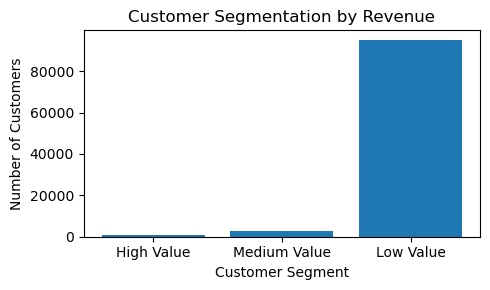

In [31]:
# Customer Analysis 3: Customer Segmentation Based on Revenue

query = """
WITH customer_revenue AS (
    SELECT
        c.customer_id,
        ROUND(SUM(oi.price),2) AS total_spent
    FROM customers c
    JOIN orders o
        ON c.customer_id = o.customer_id
    JOIN order_items oi
        ON o.order_id = oi.order_id
    GROUP BY c.customer_id
)

SELECT
    CASE
        WHEN total_spent >= 1000 THEN 'High Value'
        WHEN total_spent >= 500 THEN 'Medium Value'
        ELSE 'Low Value'
    END AS customer_segment,
    COUNT(*) AS total_customers,
    ROUND(AVG(total_spent),2) AS avg_spending
FROM customer_revenue
GROUP BY customer_segment
ORDER BY avg_spending DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Customer Segment", "Total Customers", "Average Spending"]
)

print(df)
print("\n")

plt.figure(figsize=(5,3))

plt.bar(
    df["Customer Segment"],
    df["Total Customers"]
)

plt.title("Customer Segmentation by Revenue")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

#### Insights

- The majority of customers (95,025) belong to the **Low Value** segment, with an average spending of **107.36**.
- The **High Value** segment consists of only **946 customers**, but each customer spends an average of **1,620.47**, making them the most valuable customer group.
- A small percentage of customers contributes disproportionately to revenue, highlighting the importance of customer segmentation.

#### Recommendations

- Retain High Value customers through loyalty programs, exclusive offers, and personalized experiences.
- Encourage Low and Medium Value customers to increase their spending through targeted promotions, product bundles, and cross-selling strategies.

In [77]:
print("\n")

## Customer Analysis 4: Average Products Purchased per Order by Customer City

**Business Question:**
Which customer cities purchase the highest average number of products per order?

In [33]:
# Customer Analysis 4: Average Products Purchased per Order by Customer City

query = """
WITH order_product_count AS (
    SELECT
        order_id,
        COUNT(*) AS total_products
    FROM order_items
    GROUP BY order_id
)

SELECT
    UPPER(c.customer_city) AS customer_city,
    ROUND(AVG(opc.total_products),2) AS avg_products_per_order
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_product_count opc
    ON o.order_id = opc.order_id
GROUP BY c.customer_city
ORDER BY avg_products_per_order DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Customer City", "Avg Products per Order"]
)

print(df)



        Customer City Avg Products per Order
0      PADRE CARVALHO                   7.00
1         CELSO RAMOS                   6.50
2               DATAS                   6.00
3       CANDIDO GODOI                   6.00
4      MATIAS OLIMPIO                   5.00
5             PICARRA                   4.00
6  MORRO DE SAO PAULO                   4.00
7          CIDELANDIA                   4.00
8     TEIXEIRA SOARES                   4.00
9          CURRALINHO                   4.00


In [38]:
print("\n")

# 🏪 Seller Analysis


## Seller Analysis 1: Top 10 Sellers by Revenue

**Business Question:**
Which sellers generate the highest revenue?

                          Seller ID    Revenue  Total Orders
0  4869f7a5dfa277a7dca6462dcf3b52b2  229472.63          1132
1  53243585a1d6dc2643021fd1853d8905  222776.05           358
2  4a3ca9315b744ce9f8e9374361493884  200472.92          1806
3  fa1c13f2614d7b5c4749cbc52fecda94  194042.03           585
4  7c67e1448b00f6e969d365cea6b010ab  187923.89           982
5  7e93a43ef30c4f03f38b393420bc753a  176431.87           336
6  da8622b14eb17ae2831f4ac5b9dab84a  160236.57          1314
7  7a67c85e85bb2ce8582c35f2203ad736  141745.53          1160
8  1025f0e2d44d7041d6cf58b6550e0bfa  138968.55           915
9  955fee9216a65b617aa5c0531780ce60  135171.70          1287


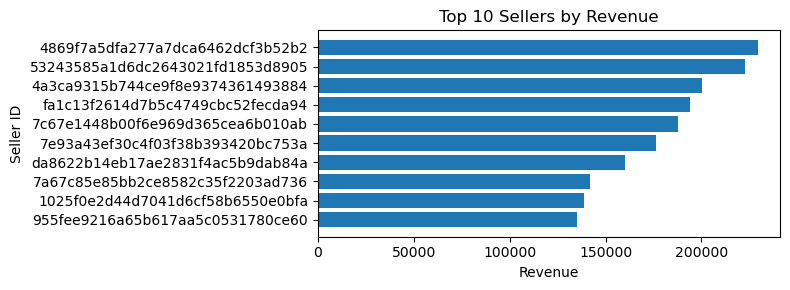

In [41]:
# Seller Analysis 1: Top 10 Sellers by Revenue

query = """
SELECT
    seller_id,
    ROUND(SUM(price),2) AS revenue,
    COUNT(DISTINCT order_id) AS total_orders
FROM order_items
GROUP BY seller_id
ORDER BY revenue DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Seller ID", "Revenue", "Total Orders"]
)

print(df)

plt.figure(figsize=(8,3))

plt.barh(df["Seller ID"], df["Revenue"])

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

#### Insights

- The top-performing seller generated **229,472.63** in revenue from **1,132 orders**.
- Higher order volume does not always result in the highest revenue, indicating differences in average order value across sellers.
- The top sellers consistently contribute a significant share of total sales, highlighting their importance to the marketplace.

#### Recommendations

- Strengthen relationships with top-performing sellers through incentives and exclusive support programs.
- Analyze the strategies of high-performing sellers and share best practices to improve the performance of other sellers.

In [78]:
print("\n")

## Seller Analysis 2: Top 10 Sellers by Number of Orders

**Business Question:**
Which sellers have fulfilled the highest number of orders?

In [47]:
# Seller Analysis 2: Top 10 Sellers by Number of Orders

query = """
SELECT
    seller_id,
    COUNT(DISTINCT order_id) AS total_orders,
    ROUND(SUM(price),2) AS revenue
FROM order_items
GROUP BY seller_id
ORDER BY total_orders DESC
LIMIT 10;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Seller ID", "Total Orders", "Revenue"]
)

print(df)

                          Seller ID  Total Orders    Revenue
0  6560211a19b47992c3666cc44a7e94c0          1854  123304.83
1  4a3ca9315b744ce9f8e9374361493884          1806  200472.92
2  cc419e0650a3c5ba77189a1882b7556a          1706  104288.42
3  1f50f920176fa81dab994f9023523100          1404  106939.21
4  da8622b14eb17ae2831f4ac5b9dab84a          1314  160236.57
5  955fee9216a65b617aa5c0531780ce60          1287  135171.70
6  7a67c85e85bb2ce8582c35f2203ad736          1160  141745.53
7  ea8482cd71df3c1969d7b9473ff13abc          1146   37177.52
8  4869f7a5dfa277a7dca6462dcf3b52b2          1132  229472.63
9  3d871de0142ce09b7081e2b9d1733cb1          1080   94914.20


#### Insights

- The highest-order seller completed **1,854 orders**, demonstrating strong sales volume.
- Sellers with the highest number of orders do not always generate the highest revenue, indicating variations in average order value.
- Order volume and revenue should be evaluated together to accurately measure seller performance.

#### Recommendations

- Recognize and reward high-volume sellers to maintain consistent marketplace activity.
- Encourage sellers with high order volumes to increase average order value through product bundles, premium offerings, and upselling strategies.

In [80]:
print("\n")

# 💳 Payment Analysis


## Payment Analysis 1: Payment Method Distribution

**Business Question:**
Which payment methods are most frequently used by customers?

  Payment Type  Total Payments
0  credit_card           76795
1          UPI           19784
2      voucher            5775
3   debit_card            1529
4  not_defined               3


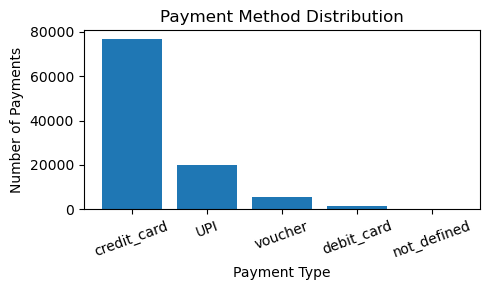

In [50]:
# Payment Analysis 1: Payment Method Distribution

query = """
SELECT
    payment_type,
    COUNT(*) AS total_payments
FROM payments
GROUP BY payment_type
ORDER BY total_payments DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["Payment Type", "Total Payments"])

print(df)

plt.figure(figsize=(5,3))

plt.bar(df["Payment Type"], df["Total Payments"])

plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Payments")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

#### Insights

- Credit Card is the most preferred payment method, accounting for the majority of transactions (76,795).
- UPI is the second most frequently used payment method, indicating strong adoption of digital payments.
- Voucher and Debit Card are used by a relatively smaller proportion of customers, while undefined payment methods are negligible.

#### Recommendations

- Continue optimizing the Credit Card and UPI payment experience to ensure smooth and secure transactions.
- Encourage the use of alternative payment methods through cashback offers or promotional discounts to improve payment flexibility.

In [81]:
print("\n")

## Payment Analysis 2: Average Payment Value by Payment Method

**Business Question:**
Which payment method has the highest average transaction value?

In [52]:
# Payment Analysis 2: Average Payment Value by Payment Method

query = """
SELECT
    payment_type,
    ROUND(AVG(payment_value),2) AS average_payment,
    ROUND(SUM(payment_value),2) AS total_payment
FROM payments
GROUP BY payment_type
ORDER BY average_payment DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Payment Type", "Average Payment", "Total Payment"]
)

print(df)

  Payment Type  Average Payment  Total Payment
0  credit_card           163.32    12542084.19
1          UPI           145.03     2869361.27
2   debit_card           142.57      217989.79
3      voucher            65.70      379436.87
4  not_defined             0.00           0.00


#### Insights

- Credit Card generated the highest total payment (**12.54M**) and also recorded the highest average payment value (**163.32**).
- UPI ranked second in both transaction value and payment volume, reflecting its growing customer adoption.
- Voucher and Debit Card contributed a much smaller share of total payment value compared to Credit Card and UPI.

#### Recommendations

- Continue optimizing Credit Card and UPI payment options to enhance customer convenience.
- Promote alternative payment methods through discounts or cashback offers to diversify payment preferences and reduce dependency on a single payment method.

In [82]:
print("\n")

# 🚚 Delivery Analysis


## Delivery Analysis 1: Average Delivery Time by State

**Business Question:**
Which customer states experience the longest average delivery time?

   State Average Delivery Days
0     RR                 29.34
1     AP                 27.18
2     AM                 26.36
3     AL                 24.50
4     PA                 23.73
5     MA                 21.51
6     SE                 21.46
7     CE                 21.20
8     AC                 21.00
9     PB                 20.39
10    PI                 19.39
11    BA                 19.28
12    RO                 19.28
13    RN                 19.22
14    PE                 18.40
15    MT                 18.00
16    TO                 17.60
17    ES                 15.72
18    GO                 15.54
19    MS                 15.54
20    RS                 15.25
21    RJ                 15.24
22    SC                 14.91
23    DF                 12.90
24    MG                 11.95
25    PR                 11.94
26    SP                  8.70


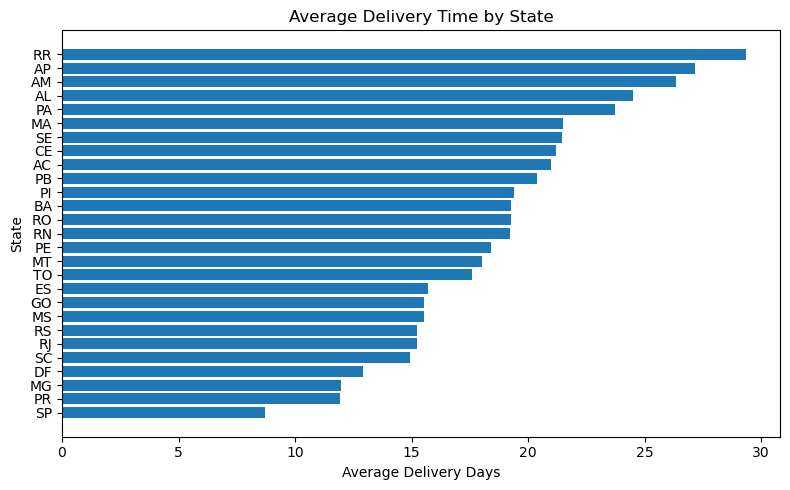

In [57]:
# Delivery Analysis 1: Average Delivery Time by State

query = """
SELECT
    c.customer_state,
    ROUND(AVG(DATEDIFF(o.order_delivered_customer_date,
                       o.order_purchase_timestamp)),2) AS avg_delivery_days
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["State", "Average Delivery Days"]
)

print(df)

plt.figure(figsize=(8,5))

plt.barh(df["State"], df["Average Delivery Days"])

plt.title("Average Delivery Time by State")
plt.xlabel("Average Delivery Days")
plt.ylabel("State")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()



#### Insights

- Delivery time varies significantly across states, ranging from **8.70 days (SP)** to **29.34 days (RR)**.
- São Paulo (SP) recorded the fastest average delivery time, indicating an efficient logistics network.
- Northern and Northeastern states generally experienced longer delivery times, highlighting regional logistics challenges.

#### Recommendations

- Optimize logistics operations and strengthen delivery partnerships in states with higher delivery times.
- Establish regional warehouses or distribution centers in slower-delivery regions to reduce shipping time and improve customer satisfaction.

In [84]:
print("\n")

## Delivery Analysis 2: Late Delivery Analysis

**Business Question:**
How many orders were delivered after the estimated delivery date?

In [58]:
# Delivery Analysis 2: Late Deliveries

query = """
SELECT
    CASE
        WHEN order_delivered_customer_date > order_estimated_delivery_date
            THEN 'Late'
        ELSE 'On Time'
    END AS delivery_status,
    COUNT(*) AS total_orders
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
GROUP BY delivery_status;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["Delivery Status", "Total Orders"]
)

print(df)

  Delivery Status  Total Orders
0         On Time         88649
1            Late          7827


#### Insights

- The majority of orders (88,649) were delivered on time, indicating strong overall delivery performance.
- Only 7,827 orders were delivered late, suggesting that the logistics network is performing efficiently for most customers.
- Although late deliveries represent a smaller proportion, they still provide an opportunity to further improve customer satisfaction.

#### Recommendations

- Monitor the root causes of late deliveries and implement corrective actions in affected regions.
- Strengthen coordination with logistics partners to further improve on-time delivery performance and enhance the customer experience.

In [85]:
print("\n")

## Delivery Analysis 3: Average Shipping Cost by State

**Business Question:**
Which customer states incur the highest average shipping cost?

In [59]:
# Delivery Analysis 3: Average Shipping Cost by State

query = """
SELECT
    c.customer_state,
    ROUND(AVG(oi.freight_value),2) AS avg_shipping_cost
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_state
ORDER BY avg_shipping_cost DESC;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(
    data,
    columns=["State", "Average Shipping Cost"]
)

df

,State,Average Shipping Cost
0,RR,42.98
1,PB,42.72
2,RO,41.07
3,AC,40.07
4,PI,39.15
5,MA,38.26
6,TO,37.25
7,SE,36.65
8,AL,35.84
9,PA,35.83


#### Insights

- Shipping costs vary significantly across states, ranging from **15.15 (SP)** to **42.98 (RR)**.
- Northern and remote states generally incur higher shipping costs, reflecting greater transportation and logistics expenses.
- São Paulo (SP) has the lowest average shipping cost, indicating a more efficient distribution network.

#### Recommendations

- Optimize logistics routes and warehouse locations to reduce shipping costs in high-cost states.
- Negotiate with logistics partners and evaluate regional fulfillment strategies to improve cost efficiency while maintaining service quality.

In [109]:
print("\n")

# Executive Summary

- This project analyzes the Target E-Commerce Sales Dataset to evaluate sales performance, customer behavior, product performance, seller performance,   payment trends, and delivery efficiency.
- Sales showed a positive growth trend over the analysis period, with revenue concentrated in major states and metropolitan cities.
- Product category analysis identified the highest revenue-generating and best-selling categories, providing insights into customer demand.
- Customer segmentation revealed that a small group of high-value customers contributes significantly to overall business revenue.
- Credit Card was the most preferred payment method, while most orders were delivered on time, reflecting efficient payment and logistics operations.
- The analysis identified opportunities to improve logistics, reduce shipping costs, and strengthen customer retention strategies.

# Final Business Recommendations

- Focus marketing efforts on high-performing states, cities, and product categories while expanding into underperforming regions.
- Strengthen customer retention through loyalty programs and personalized offers for high-value customers.
- Maintain sufficient inventory for top-selling products to avoid stock shortages.
- Improve logistics efficiency in regions with longer delivery times and higher shipping costs.
- Support top-performing sellers while helping lower-performing sellers improve through performance analysis.
- Continue enhancing digital payment options to provide a seamless customer payment experience.

# Conclusion

This project analyzed the Target E-Commerce Sales Dataset using SQL and Python to evaluate sales performance, customer behavior, product performance, seller performance, payment preferences, and delivery efficiency.

The analysis helped identify key revenue drivers, high-performing product categories, valuable customer segments, and operational improvement opportunities. The insights generated from this project can support data-driven decision-making, improve customer satisfaction, optimize logistics operations, and enhance overall business performance. This project demonstrates practical applications of SQL, Python, data visualization, and business analytics in solving real-world e-commerce business problems.

# Future Scope

- Develop an interactive Power BI dashboard for real-time business monitoring.
- Build Machine Learning models for sales forecasting and customer demand prediction.
- Predict customer churn and recommend personalized retention strategies.
- Develop product recommendation systems to improve cross-selling and upselling.
- Integrate automated reporting and real-time business monitoring for faster decision-making.

# References

- Target E-Commerce Sales Dataset – Kaggle
- MySQL Documentation
- Pandas Documentation
- Matplotlib Documentation
- Seaborn Documentation
- NumPy Documentation